# Solution to Exercise 1

## Part 1

In [39]:
import numpy as np
import matplotlib.pyplot as plt

W = 1.0
gamma = 2.0
mu = .04
epsilon = .2
Rf = 1.0

### Compute moments of risky returns

In [40]:
# Expected return
ER = .5 * (1 + mu + epsilon) + .5 * (1 + mu - epsilon)

# With vectors
probs = np.array((.5, .5))
returns = 1.0 + mu + np.array((epsilon, -epsilon))

ER = probs @ returns

# Risk premium
Rp = ER - Rf

# Sigma
var = probs @ returns**2 - ER**2
sigma = np.sqrt(var)

# Sharpe ratio
sharpe = Rp / sigma

print(f'Expected return: {ER:.2f} Risk premium: {Rp:.2f} Sharpe ratio: {sharpe:.2f}')

Expected return: 1.04 Risk premium: 0.04 Sharpe ratio: 0.20


## Part 2

In [41]:
def util(W, gamma):
    '''
    Evaluate utility of consuming W at the end of the period
    '''
    if gamma == 1:
        u = np.log(W)
    else:
        u = W**(1 - gamma) / (1 - gamma)

    return u

In [12]:
util(10, gamma=gamma)

-0.1

In [42]:
def expected_util(alpha, W, mu, epsilon, gamma):
    """
        Return the expected utility of investing a share alpha into 
        the risky asset for given parameters.

        Parameters
        ----------
        alpha: float or array
            Risky share
        W : float
            Initial wealth
        mu : float 
            Risk premium
        epsilon : float
            Volatility of risky returns
        gamma : float
            Relative risk aversion

        Returns
        -------
        float or array
            Expected utility associated with choice alpha.
    """

    # End-of-period wealth for given alpha
    probs = np.array((.5, .5))
    returns = np.array((1 + mu + epsilon, 1 + mu - epsilon))

    R_hi = (1 + mu + epsilon)
    W_hi = R_hi * alpha * W + Rf * (1-alpha) * W
    R_lo = (1 + mu - epsilon)
    W_lo = R_lo * alpha * W + Rf * (1-alpha) * W
    # Use util() from above to evaluate utility in both return realizations
    u_hi = util(W_hi, gamma=gamma)
    u_lo = util(W_lo, gamma=gamma)
    # Compute expected utility as weighted sum
    EU = .5 * u_hi + .5 * u_lo


    return EU

In [25]:
expected_util(.5, W=W, mu=mu, epsilon=epsilon, gamma=gamma)

-0.9899068322981366

## Part 3: Plot expected utility

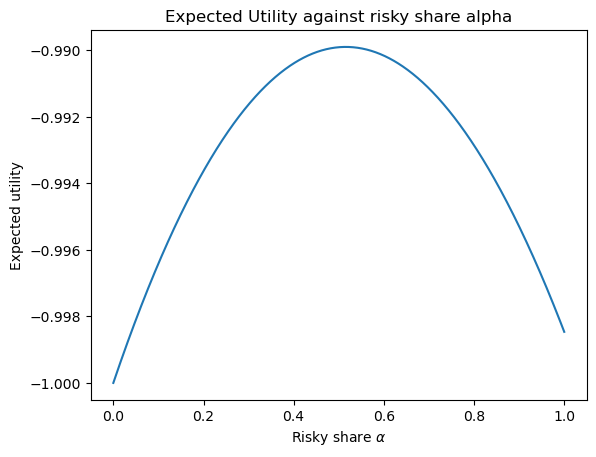

In [48]:
alpha_grid = np.linspace(0, 1, 1001)
# U = [expected_util(alpha, W, mu, epsilon, gamma) for alpha in alpha_grid]
utils = expected_util(alpha_grid, W, mu, epsilon, gamma)

plt.plot(alpha_grid, utils)
plt.title('Expected Utility against risky share alpha')
plt.xlabel(r'Risky share $\alpha$')
plt.ylabel('Expected utility')
plt.show()

## Part 4: Plot utility-maximizing alpha

EU is maximized at alpha = 0.51600 with EU = -0.98990


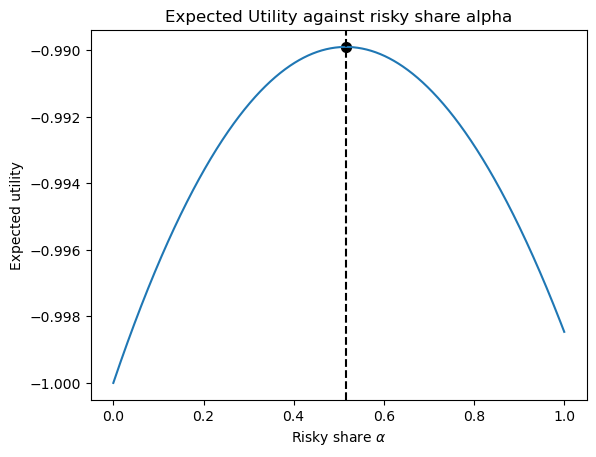

In [51]:
imax = np.argmax(utils)
amax = alpha_grid[imax]
umax = utils[imax]

print(f'EU is maximized at alpha = {amax:.5f} with EU = {umax:.5f}')

plt.plot(alpha_grid, utils)
plt.title('Expected Utility against risky share alpha')
plt.xlabel(r'Risky share $\alpha$')
plt.ylabel('Expected utility')
plt.axvline(amax, ls='--', c='black')
plt.scatter(amax, umax, s=50, c='black')
plt.show()

## Part 5

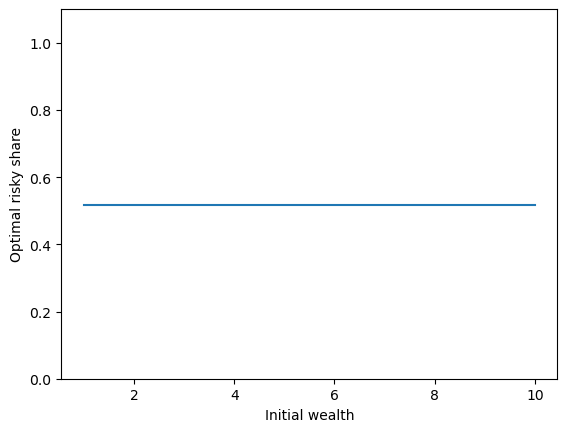

In [57]:
wealth_grid = np.linspace(1, 10, 100)

alpha_opt = []

for w in wealth_grid:
    utils = expected_util(alpha_grid, W=w, mu=mu, epsilon=epsilon, gamma=gamma)
    imax = np.argmax(utils)
    alpha_opt.append(alpha_grid[imax])


plt.plot(wealth_grid, alpha_opt)
plt.xlabel('Initial wealth')
plt.ylabel('Optimal risky share')
plt.ylim((0, 1.1))
plt.show()

Constant relative risk aversion means that the optimal risky share is equal across all levels of wealth. The initial level of wealth doesn't matter for the optimal share alpha that maximizes expeceted utility. 